In [1]:
# Agenda
# 1.Data Preparation
# 2.Exploratory Data Analysis
# 3.Data Augmentation
# 4.Data Preprocessing
# 5.Data Spliting
# 6.Model Building
# 7.Unfreezing and fine-tuning
# 8.Flask Web Application

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
import cv2
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

 # Dataset Loading

In [3]:
import zipfile

z = zipfile.ZipFile('archive (5).zip')

z.extractall()

In [4]:
folder = 'brain_tumor_dataset/yes/'
count = 1

for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + "Y_" +str(count)+".jpg"
    os.rename(source, destination)
    count+=1
print("All files are renamed in the yes dir.")

All files are renamed in the yes dir.


In [5]:
folder = 'brain_tumor_dataset/no/'
count = 1

for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + "N_" +str(count)+".jpg"
    os.rename(source, destination)
    count+=1
print("All files are renamed in the no dir.")

All files are renamed in the no dir.


# EDA

In [6]:
listyes = os.listdir("brain_tumor_dataset/yes/")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir("brain_tumor_dataset/no/")
number_files_no = len(listno)
print(number_files_no)

155
98


# Plot

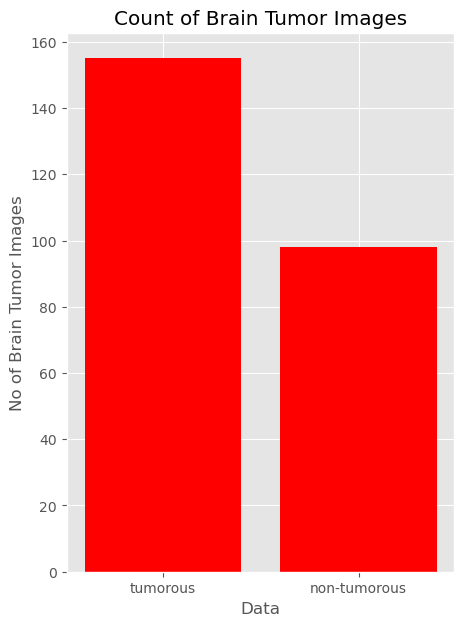

In [7]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

In [8]:
# Data Augmentation
# 155(61%), 98(39%)
# imbalance

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [10]:
def timing(sec_elapsed):
    h = int(sec_elapsed / (60*60))
    m = int(sec_elapsed % (60*60) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{s}"

In [11]:
def augmented_data(file_dir, n_generated_samples, save_to_dir):
    data_gen = ImageDataGenerator(rotation_range=10, 
                      width_shift_range=0.1,
                      height_shift_range=0.1,
                      shear_range=0.1,
                      brightness_range=(0.3, 1.0),
                      horizontal_flip=True,
                      vertical_flip=True,
                      fill_mode='nearest')
    for filename in os.listdir(file_dir):
        image = cv2.imread(file_dir + '/' + filename)
        image = image.reshape((1,) + image.shape)
        save_prefix = 'aug_' + filename[:-4]
        i=0
        for batch in data_gen.flow(x = image, batch_size = 1, save_to_dir = save_to_dir, save_prefix = save_prefix, save_format = "jpg"):
            i+=1
            if i>n_generated_samples:
                break

In [12]:
import time
start_time = time.time()

yes_path = 'brain_tumor_dataset/yes' 
no_path = 'brain_tumor_dataset/no'

augmented_data_path = 'augmented_data/'

augmented_data(file_dir = yes_path, n_generated_samples=6, save_to_dir=augmented_data_path+'yes')
augmented_data(file_dir = no_path, n_generated_samples=9, save_to_dir=augmented_data_path+'no')

end_time = time.time()
execution_time = end_time - start_time
print(timing(execution_time))

0:4:45.061532974243164


In [13]:
def data_summary(main_path):
    yes_path = "augmented_data/yes/" 
    no_path = "augmented_data/no/"
    
    n_pos = len(os.listdir(yes_path))
    n_neg = len(os.listdir(no_path))
    
    n = (n_pos + n_neg)
    
    pos_per = (n_pos*100)/n
    neg_per = (n_neg*100)/n
    
    print(f"Number of sample: {n}")
    print(f"{n_pos} Number of positive sample in percentage: {pos_per}%")
    print(f"{n_neg} Number of negative sample in percentage: {neg_per}%")

In [14]:
data_summary(augmented_data_path)


Number of sample: 2065
1085 Number of positive sample in percentage: 52.54237288135593%
980 Number of negative sample in percentage: 47.45762711864407%


In [15]:
listyes = os.listdir("augmented_data/yes/")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir("augmented_data/no/")
number_files_no = len(listno)
print(number_files_no)

1085
980


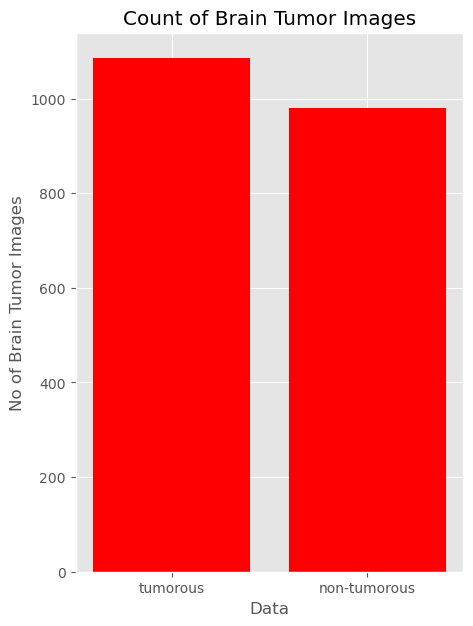

In [16]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

# Data Preprocessing

In [17]:
# Convert BGR TO GRAY
# GaussianBlur
# Threshold
# Erode
# Dilate
# Find Contours

In [18]:
import imutils
def crop_brain_tumor(image, plot=False):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    
    thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thres =cv2.erode(thres, None, iterations = 2)
    thres = cv2.dilate(thres, None, iterations = 2)
    
    cnts = cv2.findContours(thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key = cv2.contourArea)
    
    extLeft = tuple(c[c[:,:,0].argmin()][0])
    extRight = tuple(c[c[:,:,0].argmax()][0])
    extTop = tuple(c[c[:,:,1].argmin()][0])
    extBot = tuple(c[c[:,:,1].argmax()][0])
    
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]] 
    
    if plot:
        plt.figure()
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        
        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        
        plt.title('Original Image')
            
        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')
        plt.show()
    return new_image

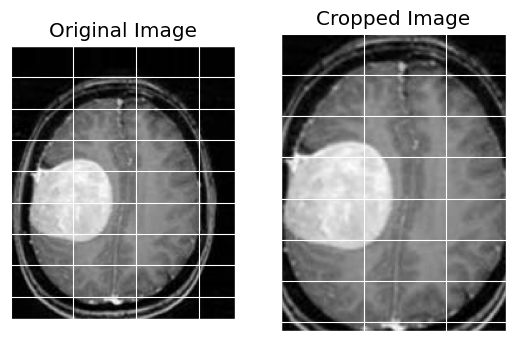

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [1, 1, 1],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]],

       [[2, 2, 2],
        [1, 1, 1],
        [2, 2, 2],
        ...,
        [3, 3, 3],
        [3, 3, 3],
        [3, 3, 3]],

       ...,

       [[5, 5, 5],
        [6, 6, 6],
        [9, 9, 9],
        ...,
        [5, 5, 5],
        [5, 5, 5],
        [6, 6, 6]],

       [[4, 4, 4],
        [5, 5, 5],
        [8, 8, 8],
        ...,
        [3, 3, 3],
        [3, 3, 3],
        [3, 3, 3]],

       [[4, 4, 4],
        [4, 4, 4],
        [2, 2, 2],
        ...,
        [2, 2, 2],
        [1, 1, 1],
        [2, 2, 2]]], dtype=uint8)

In [19]:
img = cv2.imread(r"C:\Users\HP\DL Project-2\Brain_Tumor_Detection\augmented_data\yes\aug_Y_1_0_209.jpg")
crop_brain_tumor(img, True)

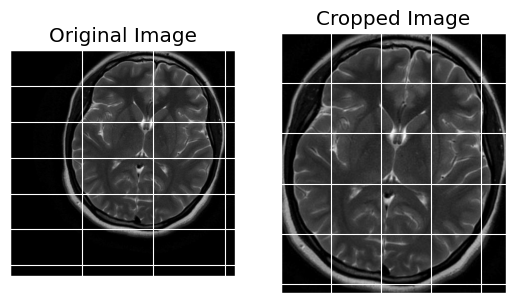

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [20]:
img = cv2.imread(r"C:\Users\HP\DL Project-2\Brain_Tumor_Detection\augmented_data\no\aug_N_1_0_75.jpg")
crop_brain_tumor(img, True)

In [21]:
folder1 = 'augmented_data/no/'
folder2 = 'augmented_data/yes/'

for filename in os.listdir(folder1):
    img = cv2.imread(folder1 + filename)
    img = crop_brain_tumor(img, False)
    cv2.imwrite(folder1 + filename, img)
for filename in os.listdir(folder2):
    img = cv2.imread(folder2 + filename)
    img = crop_brain_tumor(img, False)
    cv2.imwrite(folder2 + filename, img)

# Image loading

In [22]:
from sklearn.utils import shuffle
def load_data(dir_list, image_size):
    X=[]
    y=[]
    
    image_width, image_height=image_size
    
    for directory in dir_list:
        for filename in os.listdir(directory):
            image = cv2.imread(directory + '/' + filename)
            image = crop_brain_tumor(image, plot=False)
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation = cv2.INTER_CUBIC)
            image = image/255.00
            X.append(image)
            if directory[-3:] == "yes":
                y.append(1)
            else:
                y.append(0)
    X=np.array(X)
    y=np.array(y)
    
    X,y = shuffle(X,y)
    print(f"Number of example is : {len(X)}")
    print(f"X SHAPE is : {X.shape}")
    print(f"y SHAPE is : {y.shape}")
    return X,y

In [23]:
augmented_path = 'augmented_data/'
augmeneted_yes = augmented_path + 'yes'
augmeneted_no = augmented_path + 'no'

IMAGE_WIDTH, IMAGE_HEIGHT = (240,240)

X,y = load_data([augmeneted_yes, augmeneted_no], (IMAGE_WIDTH, IMAGE_HEIGHT))

Number of example is : 2065
X SHAPE is : (2065, 240, 240, 3)
y SHAPE is : (2065,)


In [24]:
def plot_sample_images(X, y, n=50):

    for label in [0,1]:
        images = X[np.argwhere(y == label)]
        n_images = images[:n]
        
        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))
        
        i = 1        
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])
            
            plt.tick_params(axis='both', which='both', 
                            top=False, bottom=False, left=False, right=False,
                            labelbottom=False, labeltop=False, labelleft=False,
                            labelright=False)
            
            i += 1
        
        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

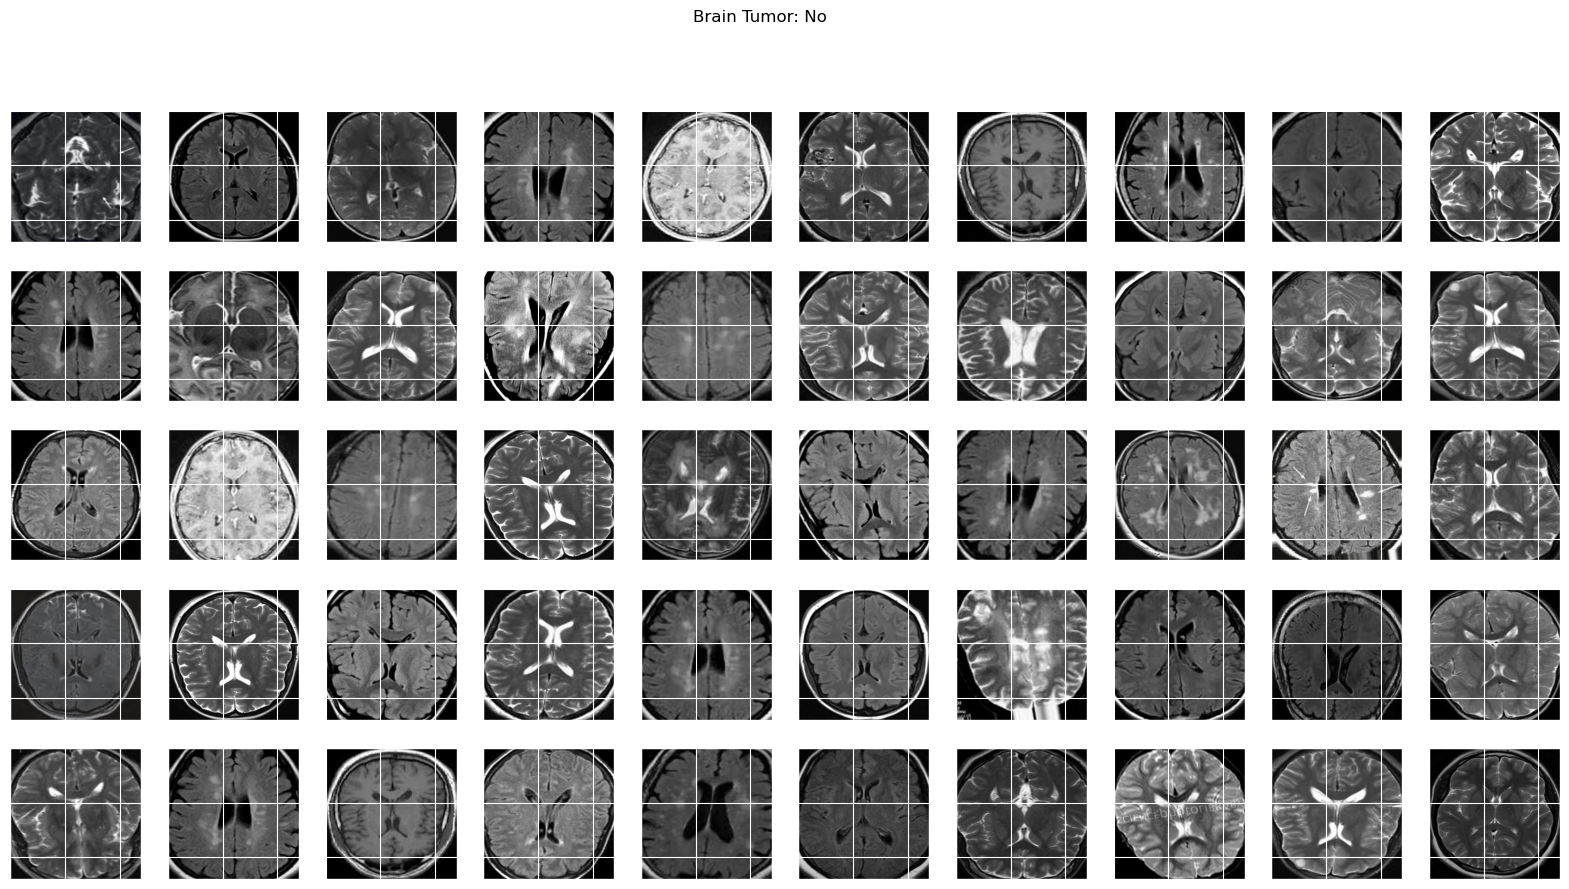

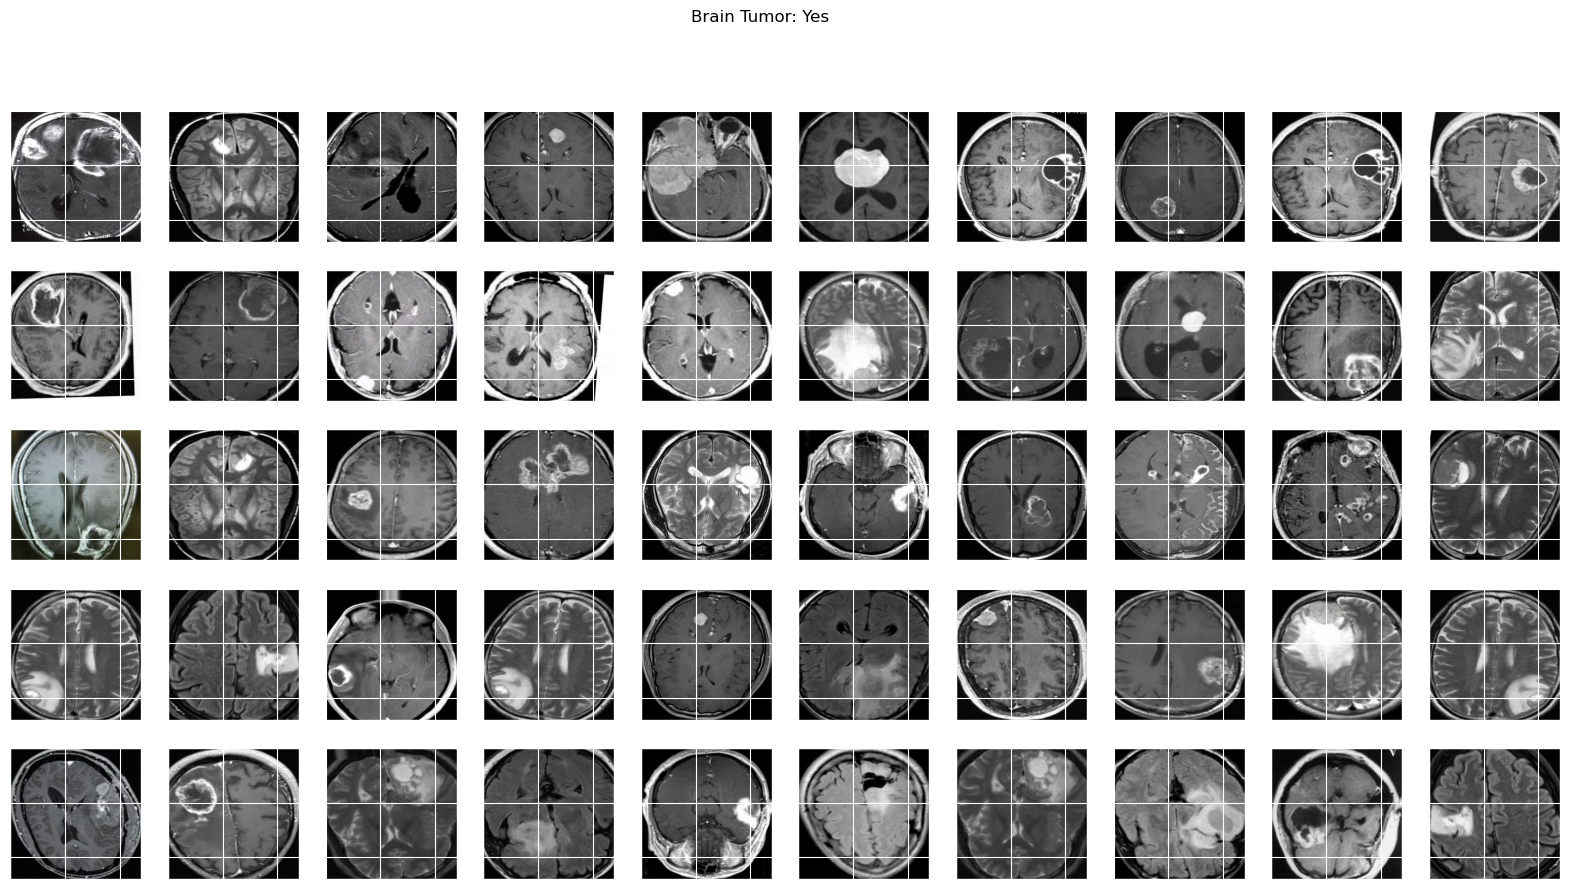

In [25]:
plot_sample_images(X,y)


In [ ]:
# Data Spliting
# Train
# Test
# Validation

In [26]:
if not os.path.isdir('tumorous_and_nontumorous'):
    base_dir = 'tumorous_and_nontumorous'
    os.mkdir(base_dir)

In [27]:
if not os.path.isdir('tumorous_and_nontumorous/train'):
    train_dir = os.path.join(base_dir , 'train')
    os.mkdir(train_dir)
if not os.path.isdir('tumorous_and_nontumorous/test'):
    test_dir = os.path.join(base_dir , 'test')
    os.mkdir(test_dir)
if not os.path.isdir('tumorous_and_nontumorous/valid'):
    valid_dir = os.path.join(base_dir , 'valid')
    os.mkdir(valid_dir)

In [28]:
if not os.path.isdir('tumorous_and_nontumorous/train/tumorous'):
    infected_train_dir = os.path.join(train_dir, 'tumorous')
    os.mkdir(infected_train_dir)
if not os.path.isdir('tumorous_and_nontumorous/test/tumorous'):
    infected_test_dir = os.path.join(test_dir, 'tumorous')
    os.mkdir(infected_test_dir)
if not os.path.isdir('tumorous_and_nontumorous/valid/tumorous'):
    infected_valid_dir = os.path.join(valid_dir, 'tumorous')
    os.mkdir(infected_valid_dir)

In [29]:
if not os.path.isdir('tumorous_and_nontumorous/train/nontumorous'):
    healthy_train_dir = os.path.join(train_dir, 'nontumorous')
    os.mkdir(healthy_train_dir)
if not os.path.isdir('tumorous_and_nontumorous/test/nontumorous'):
    healthy_test_dir = os.path.join(test_dir, 'nontumorous')
    os.mkdir(healthy_test_dir)
if not os.path.isdir('tumorous_and_nontumorous/valid/nontumorous'):
    healthy_valid_dir = os.path.join(valid_dir, 'nontumorous')
    os.mkdir(healthy_valid_dir)

In [30]:
original_dataset_tumorours = os.path.join('augmented_data','yes/')
original_dataset_nontumorours = os.path.join('augmented_data','no/')

In [31]:
files = os.listdir('augmented_data/yes/')
fnames = []
for i in range(0,759):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_train_dir, fname)
    shutil.copyfile(src, dst)

In [32]:
files = os.listdir('augmented_data/yes/')
fnames = []
for i in range(759,922):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_test_dir, fname)
    shutil.copyfile(src, dst)

In [33]:
files = os.listdir('augmented_data/yes/')
fnames = []
for i in range(922,1085):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_valid_dir, fname)
    shutil.copyfile(src, dst)

In [34]:
# 80% 10% 10%


In [35]:
files = os.listdir('augmented_data/no/')
fnames = []
for i in range(0,686):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_train_dir, fname)
    shutil.copyfile(src, dst)

In [36]:
files = os.listdir('augmented_data/no/')
fnames = []
for i in range(686,833):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_test_dir, fname)
    shutil.copyfile(src, dst)

In [37]:
files = os.listdir('augmented_data/no/')
fnames = []
for i in range(833,980):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_valid_dir, fname)
    shutil.copyfile(src, dst)

# Model Buliding


In [39]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,          # OK - brain tumors can appear symmetrically
    vertical_flip=False,           # ❌ Not recommended - brain orientation matters
    rotation_range=15,             # ✅ Lower range preferred to retain anatomical structure
    shear_range=0.1,               # ✅ Moderate shear
    width_shift_range=0.1,         # ✅ Minor shifts only
    height_shift_range=0.1,        # ✅ Minor shifts only
    zoom_range=0.1,                # ✅ Add zoom augmentation
    fill_mode='nearest'
)

test_data_gen = ImageDataGenerator(rescale=1.0/255)
valid_data_gen = ImageDataGenerator(rescale=1.0/255)


In [40]:
train_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/train/', batch_size=32, target_size=(240,240), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 1445 images belonging to 2 classes.


In [41]:
test_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/test/', batch_size=32, target_size=(240,240), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 310 images belonging to 2 classes.


In [42]:
valid_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/valid/', batch_size=32, target_size=(240,240), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 310 images belonging to 2 classes.


In [43]:
class_labels = train_generator.class_indices
class_name = {value: key for (key,value) in class_labels.items()}

In [44]:
class_name


{0: 'nontumorous', 1: 'tumorous'}

In [45]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

base_model = VGG19(input_shape=(240, 240, 3), include_top=False, weights='imagenet')

# Freeze the base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)  # ✅ Better than Flatten for spatial information
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)      # ✅ Helps stabilize and speed up training
x = Dropout(0.5)(x)              # ✅ Higher dropout to reduce overfitting
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(2, activation='softmax')(x)  # For binary classification

model_01 = Model(inputs=base_model.input, outputs=output)
model_01.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 240, 240, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 240, 240, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 240, 240, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 120, 120, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 120, 120, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 120, 120, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 60, 60, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 60, 60, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 60, 60, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 60, 60, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 60, 60, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 30, 30, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 30, 30, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 30, 30, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 30, 30, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 30, 30, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 15, 15, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,355,522 (77.65 MB)

 Trainable params: 329,858 (1.26 MB)

 Non-trainable params: 20,025,664 (76.39 MB)

In [46]:
# callback
filepath = 'model.h5'
es = EarlyStopping(monitor='val_loss', verbose = 1, mode='min',patience=4)
cp = ModelCheckpoint(filepath, monitor='val_loss', verbose = 1, save_best_only=True, save_weights_only=False, mode='auto',save_freq='epoch')
lrr = ReduceLROnPlateau(monitor='val_accuarcy', patience=3, verbose = 1, factor = 0.5, min_lr = 0.0001)

In [47]:
from tensorflow.keras.optimizers import Adam

# Define the Adam optimizer
adam = Adam(
    learning_rate=0.0001,
    beta_1=0.9,        # Exponential decay rate for the 1st moment estimates
    beta_2=0.999,      # Exponential decay rate for the 2nd moment estimates
    epsilon=1e-07      # Small constant to prevent division by zero
)

# Compile the model
model_01.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])


In [48]:
 # Assuming train_generator and valid_generator are defined correctly
history_01 = model_01.fit(
    train_generator,
    steps_per_epoch=len(train_generator),  # Total number of batches per epoch
    epochs=20,  # Consider a higher number of epochs for better training
    validation_data=valid_generator,
    validation_steps=len(valid_generator),  # Total number of batches for validation
    callbacks=[es, cp, lrr]  # Ensure callbacks are defined correctly
)


C:\Users\HP\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.5277 - loss: 1.0969 
Epoch 1: val_loss improved from inf to 0.66607, saving model to model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 1321s 29s/step - accuracy: 0.5287 - loss: 1.0945 - val_accuracy: 0.5387 - val_loss: 0.6661 - learning_rate: 1.0000e-04
Epoch 2/20


C:\Users\HP\anaconda\Lib\site-packages\keras\src\callbacks\callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_accuarcy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 32s/step - accuracy: 0.6890 - loss: 0.7431 
Epoch 2: val_loss did not improve from 0.66607
46/46 ━━━━━━━━━━━━━━━━━━━━ 1654s 36s/step - accuracy: 0.6891 - loss: 0.7427 - val_accuracy: 0.5290 - val_loss: 0.6685 - learning_rate: 1.0000e-04
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.6924 - loss: 0.6791 
Epoch 3: val_loss improved from 0.66607 to 0.65655, saving model to model.h5


...

46/46 ━━━━━━━━━━━━━━━━━━━━ 406s 9s/step - accuracy: 0.8062 - loss: 0.4484 - val_accuracy: 0.7710 - val_loss: 0.4763 - learning_rate: 1.0000e-04
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8054 - loss: 0.4833
Epoch 9: val_loss improved from 0.47634 to 0.43868, saving model to model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 408s 9s/step - accuracy: 0.8055 - loss: 0.4827 - val_accuracy: 0.7935 - val_loss: 0.4387 - learning_rate: 1.0000e-04
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7945 - loss: 0.4805
Epoch 10: val_loss did not improve from 0.43868
46/46 ━━━━━━━━━━━━━━━━━━━━ 429s 9s/step - accuracy: 0.7948 - loss: 0.4799 - val_accuracy: 0.7742 - val_loss: 0.4482 - learning_rate: 1.0000e-04
Epoch 11/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8314 - loss: 0.3866
Epoch 11: val_loss improved from 0.43868 to 0.43497, saving model to model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 411s 9s/step - accuracy: 0.8313 - loss: 0.3869 - val_accuracy: 0.7839 - val_loss: 0.4350 - learning_rate: 1.0000e-04
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8269 - loss: 0.3850
Epoch 12: val_loss improved from 0.43497 to 0.41874, saving model to model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 407s 9s/step - accuracy: 0.8269 - loss: 0.3853 - val_accuracy: 0.7968 - val_loss: 0.4187 - learning_rate: 1.0000e-04
Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8410 - loss: 0.3643
Epoch 13: val_loss improved from 0.41874 to 0.40624, saving model to model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 405s 9s/step - accuracy: 0.8410 - loss: 0.3645 - val_accuracy: 0.8258 - val_loss: 0.4062 - learning_rate: 1.0000e-04
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8474 - loss: 0.3713
Epoch 14: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 420s 9s/step - accuracy: 0.8476 - loss: 0.3708 - val_accuracy: 0.8258 - val_loss: 0.4239 - learning_rate: 1.0000e-04
Epoch 15/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8658 - loss: 0.3112
Epoch 15: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 411s 9s/step - accuracy: 0.8659 - loss: 0.3114 - val_accuracy: 0.8258 - val_loss: 0.4305 - learning_rate: 1.0000e-04
Epoch 16/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8622 - loss: 0.3514
Epoch 16: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 411s 9s/step - accuracy: 0.8621 - loss: 0.3514 - val_accuracy: 0.8258 - val_loss: 0.4386 - learning_rate: 1.0000e-04
Epoch 17/20
46/46 ━━━━━━━━━━

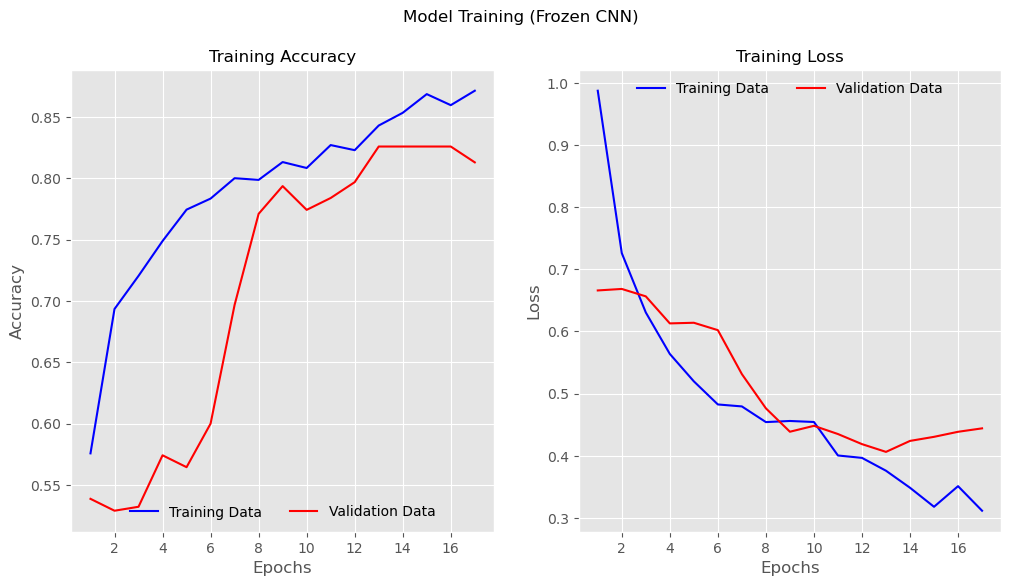

In [49]:
# Plot performance
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
fig.suptitle("Model Training (Frozen CNN)", fontsize=12)
max_epoch = len(history_01.history['accuracy'])+1
epochs_list = list(range(1, max_epoch))

ax1.plot(epochs_list, history_01.history['accuracy'], color='b', linestyle='-', label='Training Data')
ax1.plot(epochs_list, history_01.history['val_accuracy'], color='r', linestyle='-', label='Validation Data')
ax1.set_title('Training Accuracy', fontsize=12)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(frameon=False, loc='lower center', ncol=2)

ax2.plot(epochs_list, history_01.history['loss'], color='b', linestyle='-', label='Training Data')
ax2.plot(epochs_list, history_01.history['val_loss'], color='r', linestyle='-', label='Validation Data')
ax2.set_title('Training Loss', fontsize=12)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(frameon=False, loc='upper center', ncol=2)
plt.savefig("training_frozencnn.jpeg", format='jpeg', dpi=100, bbox_inches='tight')

In [50]:
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_01.save_weights(filepath="model_weights/vgg19_model_01.weights.h5", overwrite=True)

model_01.load_weights("model_weights/vgg19_model_01.weights.h5")
vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

In [52]:
print(f'Validation Loss: {vgg_val_eval_01[0]}')
print(f'Validation Acc: {vgg_val_eval_01[1]}')
print(f'Testing Loss: {vgg_test_eval_01[0]}')
print(f'Testing Acc: {vgg_test_eval_01[1]}')

Validation Loss: 0.5060405135154724
Validation Acc: 0.7870967984199524
Testing Loss: 0.4923495352268219
Testing Acc: 0.7612903118133545


In [53]:
filenames = test_generator.filenames
nb_sample = len(filenames)

vgg_prediction_01 = model_01.predict(test_generator, steps=nb_sample, verbose = 1)
y_pred = np.argmax(vgg_prediction_01, axis=1)

310/310 ━━━━━━━━━━━━━━━━━━━━ 70s 201ms/step


C:\Users\HP\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


# Increamental unfreezing and fine tuning


In [55]:
base_model = VGG19(include_top=False, input_shape=(240, 240, 3))
base_model_layer_names = [layer.name for layer in base_model.layers] 
base_model_layer_names

['input_layer_1',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_conv4',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_conv4',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_conv4',
 'block5_pool']

In [56]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Load base VGG19 model without top layers
base_model = VGG19(include_top=False, input_shape=(240, 240, 3), weights='imagenet')

# Unfreeze deeper layers for fine-tuning
for layer in base_model.layers:
    if layer.name in ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_conv4']:
        layer.trainable = True
    else:
        layer.trainable = False

# Build the top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(4608, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(1152, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Output layer for 2-class classification (use softmax if labels are one-hot encoded)
output = Dense(2, activation='softmax')(x)

# Create the final model
model_02 = Model(inputs=base_model.input, outputs=output)
#model_02.load_weights('model_weights/vgg19_model_01.weights.h5')

# Print model summary
model_02.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 240, 240, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 240, 240, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 240, 240, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 120, 120, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 120, 120, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 120, 120, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 60, 60, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 60, 60, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 60, 60, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 60, 60, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 60, 60, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 30, 30, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 30, 30, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 30, 30, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 30, 30, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 30, 30, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 15, 15, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 27,723,202 (105.76 MB)

 Trainable params: 17,126,530 (65.33 MB)

 Non-trainable params: 10,596,672 (40.42 MB)

In [57]:
from tensorflow.keras.optimizers import Adam

# Define Adam optimizer
adam = Adam(
    learning_rate=0.0001,  # Recommended small LR for fine-tuning
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# Compile the model with Adam
model_02.compile(
    loss='categorical_crossentropy',
    optimizer=adam,
    metrics=['accuracy']
)


In [58]:
history_02 = model_02.fit(
    train_generator,
    steps_per_epoch=len(train_generator),  # Number of batches per epoch
    epochs=30,  # More epochs for convergence
    validation_data=valid_generator,
    validation_steps=len(valid_generator),
    callbacks=[es, cp, lrr],
    verbose=1
)

Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7211 - loss: 3.3897
Epoch 1: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 546s 12s/step - accuracy: 0.7229 - loss: 3.3837 - val_accuracy: 0.7161 - val_loss: 3.0645 - learning_rate: 1.0000e-04
Epoch 2/30


C:\Users\HP\anaconda\Lib\site-packages\keras\src\callbacks\callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_accuarcy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9102 - loss: 2.6896
Epoch 2: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 489s 11s/step - accuracy: 0.9103 - loss: 2.6874 - val_accuracy: 0.5258 - val_loss: 3.0127 - learning_rate: 1.0000e-04
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9432 - loss: 2.3816
Epoch 3: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 494s 11s/step - accuracy: 0.9435 - loss: 2.3802 - val_accuracy: 0.6484 - val_loss: 2.6898 - learning_rate: 1.0000e-04
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9575 - loss: 2.2204
Epoch 4: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 482s 10s/step - accuracy: 0.9577 - loss: 2.2190 - val_accuracy: 0.5710 - val_loss: 3.1188 - learning_rate: 1.0000e-04
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9619 - loss: 2.1386
Epoch 5: val_loss did not improve from 0.40624
46/46 ━━━━━━━━━━━━━━━━━━━━ 479s 11s/step - accuracy: 0.9

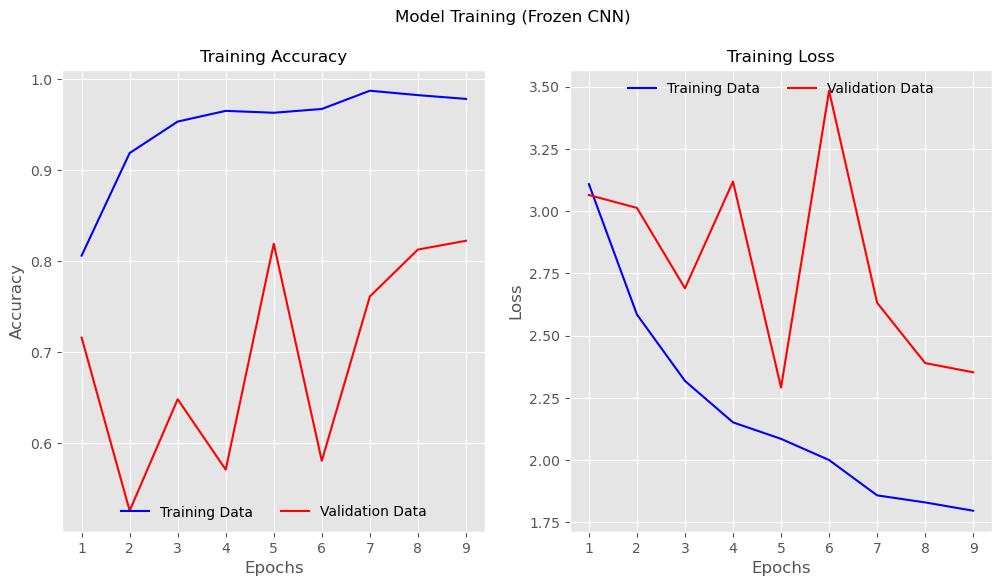

In [60]:
# Plot performance
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle("Model Training (Frozen CNN)", fontsize=12)

# Dynamically set epoch list based on history_02
max_epoch = len(history_02.history['accuracy'])
epochs_list = list(range(1, max_epoch + 1))

# Accuracy plot
ax1.plot(epochs_list, history_02.history['accuracy'], color='b', linestyle='-', label='Training Data')
ax1.plot(epochs_list, history_02.history['val_accuracy'], color='r', linestyle='-', label='Validation Data')
ax1.set_title('Training Accuracy', fontsize=12)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(frameon=False, loc='lower center', ncol=2)

# Loss plot
ax2.plot(epochs_list, history_02.history['loss'], color='b', linestyle='-', label='Training Data')
ax2.plot(epochs_list, history_02.history['val_loss'], color='r', linestyle='-', label='Validation Data')
ax2.set_title('Training Loss', fontsize=12)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(frameon=False, loc='upper center', ncol=2)

# Save the figure
plt.savefig("training_frozencnn.jpeg", format='jpeg', dpi=100, bbox_inches='tight')
plt.show()


In [62]:
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')

model_02.save_weights(filepath="model_weights/vgg19_model_02.weights.h5", overwrite=True)


In [63]:
model_02.load_weights("model_weights/vgg19_model_02.weights.h5")
vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)


10/10 ━━━━━━━━━━━━━━━━━━━━ 73s 7s/step - accuracy: 0.8348 - loss: 2.3520
10/10 ━━━━━━━━━━━━━━━━━━━━ 75s 8s/step - accuracy: 0.8318 - loss: 2.1663
